In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patches as patches
from matplotlib.patches import Ellipse

In [28]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import MONITORING_DATA, color_mapping, class_it_mapping

In [ ]:
pcsv= MONITORING_DATA /"4.Tables_for_figures/tables_AC_plots/"

p_save_fig = MONITORING_DATA / "Figures_Values/"



# per site (over years)

In [35]:
folder = "persite"
df_site = pd.read_csv( pcsv /f"{folder}/row_coordinates.csv")
df_taxa= pd.read_csv( pcsv/f"{folder}/col_coordinates.csv") 
eigenvalues = pd.read_csv( pcsv /f"{folder}/eigenvalues.csv") 
circles = pd.read_csv( pcsv /f"{folder}/circles.csv") 
cos = pd.read_csv( pcsv /f"{folder}/cos2_values.csv") 

eigenvalues.head()





,dims,eigenvalue,percentage of variance,cumulative percentage of variance
0,dim 1,0.267428,39.109963,39.109963
1,dim 2,0.152339,22.278713,61.388677
2,dim 3,0.129562,18.947678,80.336355
3,dim 4,0.063527,9.290477,89.626832
4,dim 5,0.050620,7.402916,97.029748


In [36]:
dim1 = eigenvalues[eigenvalues["dims"] == "dim 1"]["percentage of variance"].values[0]
print(dim1)

dim2 = eigenvalues[eigenvalues["dims"] == "dim 2"]["percentage of variance"].values[0]
print(dim2)

dim3 = eigenvalues[eigenvalues["dims"] == "dim 3"]["percentage of variance"].values[0]
print(dim3)

39.1099634388599
22.2787133286963
18.9476779176785


In [37]:
df_site.head()

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,site
0,-0.340787,-0.117065,0.021694,-0.069211,-0.385147,D1
1,-0.603235,-0.114897,0.635616,0.123438,0.245827,D2
2,-0.318253,0.180563,-0.078518,-0.465480,-0.052655,D3
3,0.377693,0.616549,-0.167301,-0.069059,0.255503,W1
4,-0.342541,-0.428167,-0.653832,0.187640,0.154857,W2


In [39]:
df_taxa['classe_it'] = df_taxa['classes'].replace(class_it_mapping)
df_taxa['color'] = df_taxa['classes'].map(color_mapping)
df_taxa["classe_nb"] = [el+1 for el in df_taxa.index]
df_taxa.head()


,classes,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,classe_it,color,classe_nb
0,QuercusDeciduous,-0.060592,-0.084555,-0.285052,0.033304,0.019119,$\it{Quercus}$ $\it{deciduous}$,#33a02c,1
1,QuercusIlex,-0.197278,-0.482180,-0.607428,0.241898,0.142116,$\it{Quercus}$ $\it{ilex}$,darkgreen,2
2,Buxus,1.496413,-0.960695,0.416685,-0.274745,-0.024805,$\it{Buxus}$,seagreen,3
3,Phillyrea,0.828064,0.576845,-0.036119,0.090453,0.281331,$\it{Phillyrea}$,#b2df8a,4
4,Fraxinus,0.709407,0.604257,0.067128,0.553746,-0.185754,$\it{Fraxinus}$,mediumaquamarine,5


In [40]:
class_nb_mapping = {cls: i for i, cls in enumerate(df_taxa['classes'].unique())}

markers_sites=['X', 'X', 'X', 'X', 's', 's', 's']
sitemarker_mapping =  { "D1" : "s", "D2" : "s", "D3" : "s", "W1" : "X", "W2" : "X", "W3" : "X", "W4" : "X" }

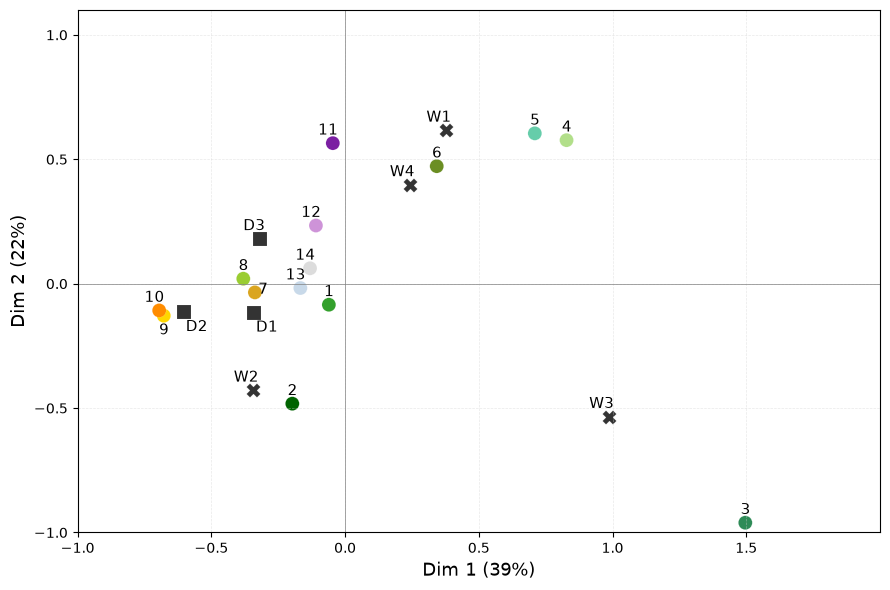

In [41]:
plt.figure(figsize=(9,6)) 
for site, marker in zip(df_site["site"].unique(), markers_sites):
    site_data = df_site[df_site["site"] == site]
    plt.scatter(site_data["Dim 1"], site_data["Dim 2"],
                marker=sitemarker_mapping[site], color="black", s=100, alpha=0.8,
                edgecolor='w', linewidths=0.1, label=site)

scatter = plt.scatter(data=df_taxa, x='Dim 1', y='Dim 2', 
                      c=df_taxa['color'], s=100, marker='o',  
                      edgecolor="w", linewidths=0.1)

for idx, row in df_taxa.iterrows():
    dx = 0.02
    dy = 0.02
    taxa_code = row["classe_nb"]
    if taxa_code==7:
        dy=-0.02
        dx = 0.05
    elif taxa_code==9:
        dy=-0.09
        dx = 0.02
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy, f'{taxa_code}', 
             fontsize=11, ha='right', va='bottom', color='black')

for idx, row in df_site.iterrows():
    dx = 0.02
    dy = 0.02
    site_code = row['site']
    site_label = site_code
    text_color = "black"
    if site_code=="D2" or site_code=="D1":
        dy=-0.09
        dx = 0.09
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy, f'{site_label}', 
             fontsize=11, ha='right', va='bottom', color=text_color, 
              alpha=1) 



handles_taxa = [plt.Line2D([0], [0], marker='.', color='w',
                           markeredgecolor='black', markeredgewidth=0.5,
                           markerfacecolor=color_mapping[cls], markersize=10) for cls in df_taxa["classes"]]
labels_taxa = list(sorted(df_taxa["classe_nb"])) 
plt.ylim(-1, 1.1) 
plt.xlim(-1, 2) 
plt.gca().legend().set_visible(False)

plt.title("", size=10)
plt.xlabel(f'Dim 1 ({int(dim1)}%)', fontsize=13)
plt.ylabel(f'Dim 2 ({int(dim2)}%)', fontsize=13)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)  
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)  
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5) 
plt.xticks(np.arange(-1, 2, 0.5), fontsize=10)  
plt.yticks(np.arange(-1, 1.1, 0.5), fontsize=10)  
plt.tight_layout()

plt.savefig(p_save_fig / f"AC_percentages_persite_withOther.svg", bbox_inches="tight", format="svg") # XXXX old for me
plt.savefig(p_save_fig / f"AC_percentages_persite_withOther.pdf", bbox_inches="tight")
plt.show()

# per site and years

In [48]:
folder = "persite_peryear"
df_taxa= pd.read_csv( pcsv/f"{folder}/col_coordinates.csv") 
eigenvalues = pd.read_csv( pcsv /f"{folder}/eigenvalues.csv") 
circles = pd.read_csv( pcsv /f"{folder}/circles.csv") 
df_site = pd.read_csv( pcsv /f"{folder}/row_coordinates.csv")

df_site.head()

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,site_year,site
0,-0.107554,-0.252153,0.299440,-0.212780,0.126607,D1_2019,D1
1,-0.356614,-0.112568,0.396444,-0.152874,0.154220,D1_2020,D1
2,-0.305593,-0.225276,-0.006454,0.193769,0.011300,D1_2021,D1
3,-0.461499,-0.147972,0.552135,0.303580,-0.098204,D2_2020,D2
4,-0.502089,-0.246997,0.506792,0.728824,-0.252315,D2_2021,D2


In [49]:
# Load the data exported from R
df_rows = pd.read_csv( pcsv /f"{folder}/row_coordinates.csv")
df_rows['site'] = [el.split("_")[0] for el in df_rows['site_year']]
df_cols =pd.read_csv( pcsv/f"{folder}/col_coordinates.csv") 
df_eig =pd.read_csv( pcsv /f"{folder}/eigenvalues.csv") 

In [51]:
dim1 = eigenvalues[eigenvalues["dims"] == "dim 1"]["percentage of variance"].values[0]
print(dim1)

dim2 = eigenvalues[eigenvalues["dims"] == "dim 2"]["percentage of variance"].values[0]
print(dim2)

dim3 = eigenvalues[eigenvalues["dims"] == "dim 3"]["percentage of variance"].values[0]
print(dim3)

29.8058069968192
21.8452462840614
17.5588022831871


In [53]:
dict_col_site = {"W4" : "darkgreen", "D1" : "darkorange",  "D2" : "darkorange",  "D3" : "darkorange", "W1" : "darkgreen", "W3" : "darkgreen", "W2" : "darkgreen"}
df_site["site"] = [el.split("_")[0] for el in df_site["site_year"]]
df_site["year"] = [el.split("_")[1] for el in df_site["site_year"]]
df_site["colors_site"] = [el.replace(el, dict_col_site[el]) for el in df_site["site"]]
df_site = df_site.rename(columns={'index': 'site_year'})
df_site.head()

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,site_year,site,year,colors_site
0,-0.107554,-0.252153,0.299440,-0.212780,0.126607,D1_2019,D1,2019,darkorange
1,-0.356614,-0.112568,0.396444,-0.152874,0.154220,D1_2020,D1,2020,darkorange
2,-0.305593,-0.225276,-0.006454,0.193769,0.011300,D1_2021,D1,2021,darkorange
3,-0.461499,-0.147972,0.552135,0.303580,-0.098204,D2_2020,D2,2020,darkorange
4,-0.502089,-0.246997,0.506792,0.728824,-0.252315,D2_2021,D2,2021,darkorange


In [54]:
df_taxa["classe_nb"] = [el+1 for el in df_taxa.index]
df_taxa.head()


,classes,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,classe_nb
0,QuercusDeciduous,-0.018637,-0.099237,-0.221649,-0.011254,0.112540,1
1,QuercusIlex,-0.158142,-0.555040,-0.798898,0.123025,-0.039893,2
2,Buxus,2.142455,-1.013908,0.546059,-0.099333,-0.024128,3
3,Phillyrea,0.688404,1.046876,-0.323645,0.172532,-0.659332,4
4,Fraxinus,0.476861,0.806556,-0.156572,0.264908,0.695357,5


In [55]:
df_taxa['classe_it'] = df_taxa['classes'].replace(class_it_mapping)
df_taxa

,classes,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,classe_nb,classe_it
0,QuercusDeciduous,-0.018637,-0.099237,-0.221649,-0.011254,0.112540,1,$\it{Quercus}$ $\it{deciduous}$
1,QuercusIlex,-0.158142,-0.555040,-0.798898,0.123025,-0.039893,2,$\it{Quercus}$ $\it{ilex}$
2,Buxus,2.142455,-1.013908,0.546059,-0.099333,-0.024128,3,$\it{Buxus}$
3,Phillyrea,0.688404,1.046876,-0.323645,0.172532,-0.659332,4,$\it{Phillyrea}$
4,Fraxinus,0.476861,0.806556,-0.156572,0.264908,0.695357,5,$\it{Fraxinus}$
5,Olea,0.018620,0.451754,0.028513,-0.287790,0.060434,6,$\it{Olea}$
6,Cupressaceae,-0.219035,-0.141235,0.070998,0.192012,0.101545,7,Cupressaceae
7,Pistacia,-0.360555,-0.089453,0.484898,-0.251856,0.184139,8,$\it{Pistacia}$
8,Poaceae,-0.554841,-0.174859,0.743949,0.655968,-0.241770,9,Poaceae
9,Plantago,-0.583702,-0.182087,0.770094,0.617778,-0.319839,10,$\it{Plantago}$


In [56]:


di_other={}
di_main={}

for k in color_mapping.keys():
    if color_mapping[k]=="grey":
        di_other[k]=color_mapping[k]
    else:
        di_main[k]=color_mapping[k]

df_taxa=df_taxa.copy()
df_site=df_site.copy()

df_taxa['color'] = df_taxa['classes'].map(color_mapping)

df_taxa


,classes,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,classe_nb,classe_it,color
0,QuercusDeciduous,-0.018637,-0.099237,-0.221649,-0.011254,0.112540,1,$\it{Quercus}$ $\it{deciduous}$,#33a02c
1,QuercusIlex,-0.158142,-0.555040,-0.798898,0.123025,-0.039893,2,$\it{Quercus}$ $\it{ilex}$,darkgreen
2,Buxus,2.142455,-1.013908,0.546059,-0.099333,-0.024128,3,$\it{Buxus}$,seagreen
3,Phillyrea,0.688404,1.046876,-0.323645,0.172532,-0.659332,4,$\it{Phillyrea}$,#b2df8a
4,Fraxinus,0.476861,0.806556,-0.156572,0.264908,0.695357,5,$\it{Fraxinus}$,mediumaquamarine
5,Olea,0.018620,0.451754,0.028513,-0.287790,0.060434,6,$\it{Olea}$,olivedrab
6,Cupressaceae,-0.219035,-0.141235,0.070998,0.192012,0.101545,7,Cupressaceae,goldenrod
7,Pistacia,-0.360555,-0.089453,0.484898,-0.251856,0.184139,8,$\it{Pistacia}$,yellowgreen
8,Poaceae,-0.554841,-0.174859,0.743949,0.655968,-0.241770,9,Poaceae,gold
9,Plantago,-0.583702,-0.182087,0.770094,0.617778,-0.319839,10,$\it{Plantago}$,darkorange


In [58]:
print(class_it_mapping)
df_site["site"] = [el.split("_")[0] for el in df_site["site_year"]]
df_site["year"] = [el.split("_")[1] for el in df_site["site_year"]]

df_site.head()

{'Buxus': '$\\it{Buxus}$', 'Cupressaceae': 'Cupressaceae', 'Fraxinus': '$\\it{Fraxinus}$', 'IndetBlurry': 'Indet. (blurry)', 'IndetCovered': 'Indet. (covered)', 'Lycopodium': '$\\it{Lycopodium}$', 'NonPollen': 'non pollen', 'Olea': '$\\it{Olea}$', 'Phillyrea': '$\\it{Phillyrea}$', 'Pinaceae': 'Pinaceae', 'Pistacia': '$\\it{Pistacia}$', 'Plantago': '$\\it{Plantago}$', 'Poaceae': 'Poaceae', 'QuercusDeciduous': '$\\it{Quercus}$ $\\it{deciduous}$', 'QuercusIlex': '$\\it{Quercus}$ $\\it{ilex}$', 'VitisF': '$\\it{Vitis}$ fertile', 'VitisS': '$\\it{Vitis}$ sterile', 'Other': 'Non-target taxa'}


,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5,site_year,site,year,colors_site
0,-0.107554,-0.252153,0.299440,-0.212780,0.126607,D1_2019,D1,2019,darkorange
1,-0.356614,-0.112568,0.396444,-0.152874,0.154220,D1_2020,D1,2020,darkorange
2,-0.305593,-0.225276,-0.006454,0.193769,0.011300,D1_2021,D1,2021,darkorange
3,-0.461499,-0.147972,0.552135,0.303580,-0.098204,D2_2020,D2,2020,darkorange
4,-0.502089,-0.246997,0.506792,0.728824,-0.252315,D2_2021,D2,2021,darkorange


In [59]:

color_mappingYEAR = {
    2023: "#BBBBBB", 
    2022: "#888888",  
    2021: "#555555",  
    2020: "#222222", 
    2019: "#000000"   
}


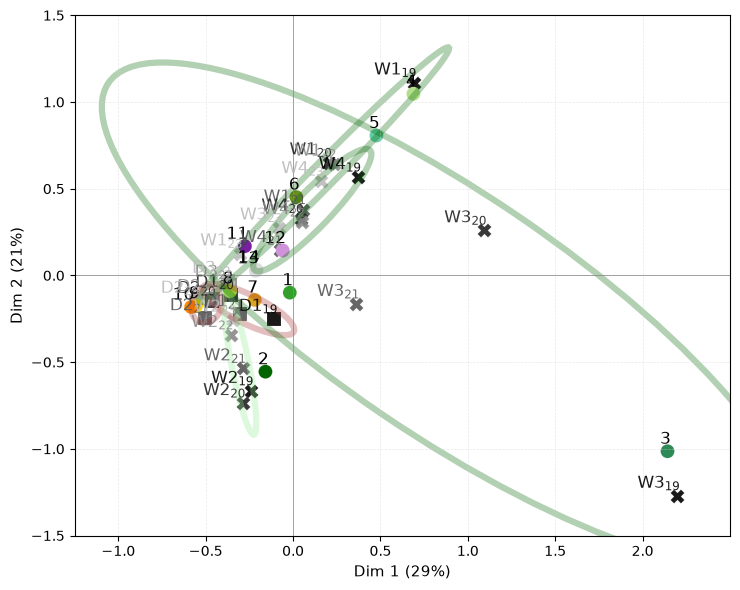

In [63]:

sitecolor_mapping = {"W1": "darkgreen", "W2": "lightgreen", "W3": "darkgreen", "W4": "darkgreen",
                "D1": "brown", "D2": "brown", "D3": "brown"}


plt.figure(figsize=(7.5,6)) 

pc1 = round(df_eig.iloc[0, 1], 1)
pc2 = round(df_eig.iloc[1, 1], 1)


ax = plt.gca()
for siteyear in df_site["site_year"].unique():
    site_data = df_site[df_site["site_year"] == siteyear]
    site = siteyear.split("_")[0]
    year= siteyear.split("_")[1]
    plt.scatter(site_data["Dim 1"], site_data["Dim 2"],
                marker=sitemarker_mapping[site], color=color_mappingYEAR[(int(year))], s=100, alpha=0.9,
                edgecolor='w', linewidths=0.1, label=site)

scatter = plt.scatter(data=df_taxa,x='Dim 1', y='Dim 2',
                      c=df_taxa['color'], s=100, marker='o',  
                      edgecolor="w", linewidths=0.1)

for idx, row in df_taxa.iterrows():
    dx = 0.02
    dy = 0.02
    taxa_code = row["classe_nb"]
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy, f'{taxa_code}', 
             fontsize=12, ha='right', va='bottom', color='black')

for idx, row in df_site.iterrows():
    dx = 0.02
    dy = 0.02
    site_code = row['site']
    year_code = row["year"]
    site_label = site_code
    label = rf"{site_label}$_{{{year_code[-2:]}}}$"
    text_color = color_mappingYEAR[int(year_code)]
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy,label, 
             fontsize=12, ha='right', va='bottom', color=text_color, 
             alpha=0.9) 



for site_code, group in df_site.groupby('site'):
    ell_color = sitecolor_mapping.get(site_code, "black")
    
    x = group['Dim 1'].values
    y = group['Dim 2'].values
    
    if len(group) > 2: # at least 3 points to calculate a meaningful covariance/ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        n_std = 2 # 2.0 is roughly 95% of the data distribution
        
        width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0)) # max(vals, 0) to prevent errors with very small negative floats
        
        # Create the ellipse
        ell = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height, angle=theta,
                      edgecolor=ell_color, 
                      facecolor='none',
                      alpha=0.3,    
                      lw=4.5,       
                      linestyle='-') 
        
        ax.add_patch(ell)


handles_taxa = [plt.Line2D([0], [0], marker='.', color='w',
                           markeredgecolor='black', markeredgewidth=0,
                           markerfacecolor=color_mapping[cls], markersize=10) for cls in df_taxa["classes"]]
labels_taxa = list(sorted(df_taxa["classe_nb"])) 

handles_years = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color, markersize=8,
                           markeredgecolor='black', markeredgewidth=0)
                for year, color in color_mappingYEAR.items()]

labels_years = [str(year) for year in color_mappingYEAR.keys()]


plt.title("", size=10)
plt.xlabel(f'Dim 1 ({int(dim1)}%)', fontsize=11)
plt.ylabel(f'Dim 2 ({int(dim2)}%)', fontsize=11)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)  
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5) 
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5) 
plt.ylim(-1.5, None)
plt.xlim(None, 2.5)
plt.xticks(np.arange(-1, 2.50, 0.5))
plt.yticks(np.arange(-1.5, 2, 0.5))

plt.tight_layout()
plt.savefig(p_save_fig / f"AC_percentages_persiteperyear_withOther.pdf", bbox_inches="tight")

plt.show()

## separating plots with only sites or only taxa

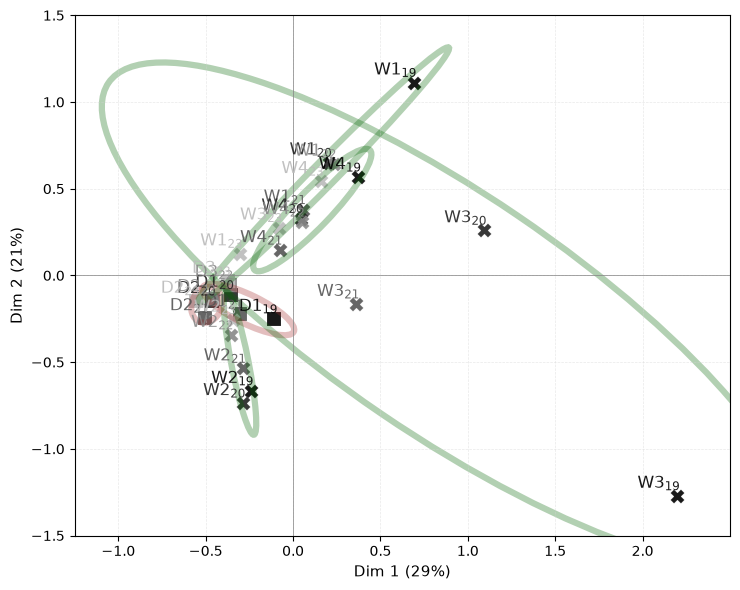

In [64]:
# ONLY SITES

sitecolor_mapping = {"W1": "darkgreen", "W2": "darkgreen", "W3": "darkgreen", "W4": "darkgreen",
                "D1": "brown", "D2": "brown", "D3": "brown"}


plt.figure(figsize=(7.5,6)) 

pc1 = round(df_eig.iloc[0, 1], 1)
pc2 = round(df_eig.iloc[1, 1], 1)


ax = plt.gca()
for siteyear in df_site["site_year"].unique():
    site_data = df_site[df_site["site_year"] == siteyear]
    site = siteyear.split("_")[0]
    year= siteyear.split("_")[1]
    plt.scatter(site_data["Dim 1"], site_data["Dim 2"],
                marker=sitemarker_mapping[site], color=color_mappingYEAR[(int(year))], s=100, alpha=0.9,
                edgecolor='w', linewidths=0.1, label=site)



for idx, row in df_site.iterrows():
    dx = 0.02
    dy = 0.02
    site_code = row['site']
    year_code = row["year"]
    site_label = site_code
    label = rf"{site_label}$_{{{year_code[-2:]}}}$"
    text_color = color_mappingYEAR[int(year_code)]
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy,label, 
             fontsize=12, ha='right', va='bottom', color=text_color, 
             alpha=0.9) # fontweight='bold', 



# --- ADAPTED ELLIPSE SECTION START ---
for site_code, group in df_site.groupby('site'):
    ell_color = sitecolor_mapping.get(site_code, "black")
    
    x = group['Dim 1'].values
    y = group['Dim 2'].values
    
    if len(group) > 2: # at least 3 points to calculate a meaningful covariance/ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        
        # Sort eigenvalues to find the primary axis
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        
        # Calculate rotation angle
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        n_std = 2 # 2.0 is roughly 95% of the data distribution
        
        width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0)) # max(vals, 0) to prevent errors with very small negative floats
        
        # Create the ellipse
        ell = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height, angle=theta,
                      edgecolor=ell_color, 
                      facecolor='none', #ell_color, 
                      alpha=0.3,    
                      lw=4.5,       
                      linestyle='-') 
        
        ax.add_patch(ell)
# --- ADAPTED ELLIPSE SECTION END ---


handles_taxa = [plt.Line2D([0], [0], marker='.', color='w',
                           markeredgecolor='black', markeredgewidth=0,
                           markerfacecolor=color_mapping[cls], markersize=10) for cls in df_taxa["classes"]]
labels_taxa = list(sorted(df_taxa["classe_nb"])) 

handles_years = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color, markersize=8,
                           markeredgecolor='black', markeredgewidth=0)
                for year, color in color_mappingYEAR.items()]

labels_years = [str(year) for year in color_mappingYEAR.keys()]


plt.title("", size=10)
plt.xlabel(f'Dim 1 ({int(dim1)}%)', fontsize=11)
plt.ylabel(f'Dim 2 ({int(dim2)}%)', fontsize=11)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)  
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5) 
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5) 
plt.ylim(-1.5, None)
plt.xlim(None, 2.5)
plt.xticks(np.arange(-1, 2.50, 0.5))
plt.yticks(np.arange(-1.5, 2, 0.5))

plt.tight_layout()
plt.savefig(p_save_fig / f"AC_percentages_persiteperyear_withOther_siteonly.pdf", bbox_inches="tight")

plt.show()

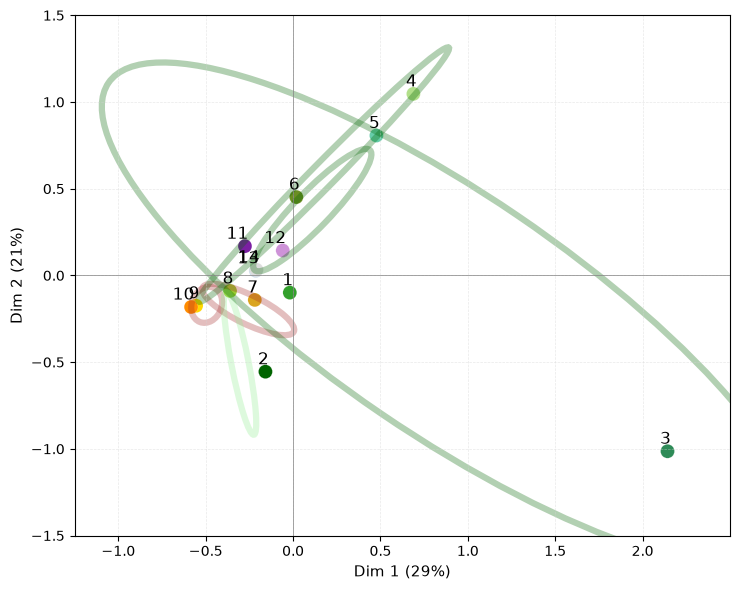

In [65]:
# ONLY TAXA

sitecolor_mapping = {"W1": "darkgreen", "W2": "lightgreen", "W3": "darkgreen", "W4": "darkgreen",
                "D1": "brown", "D2": "brown", "D3": "brown"}


plt.figure(figsize=(7.5,6)) 

pc1 = round(df_eig.iloc[0, 1], 1)
pc2 = round(df_eig.iloc[1, 1], 1)


ax = plt.gca()


scatter = plt.scatter(data=df_taxa,x='Dim 1', y='Dim 2',
                      c=df_taxa['color'], s=100, marker='o',  
                      edgecolor="w", linewidths=0.1)

for idx, row in df_taxa.iterrows():
    dx = 0.02
    dy = 0.02
    taxa_code = row["classe_nb"]
    plt.text(row['Dim 1'] + dx, row['Dim 2'] + dy, f'{taxa_code}', 
             fontsize=12, ha='right', va='bottom', color='black')


# --- ADAPTED ELLIPSE SECTION START ---
for site_code, group in df_site.groupby('site'):
    ell_color = sitecolor_mapping.get(site_code, "black")
    
    x = group['Dim 1'].values
    y = group['Dim 2'].values
    
    if len(group) > 2: # at least 3 points to calculate a meaningful covariance/ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        
        # Sort eigenvalues to find the primary axis
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        
        # Calculate rotation angle
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        n_std = 2 # 2.0 is roughly 95% of the data distribution
        
        width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0)) # max(vals, 0) to prevent errors with very small negative floats
        
        # Create the ellipse
        ell = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height, angle=theta,
                      edgecolor=ell_color, 
                      facecolor='none', #ell_color, 
                      alpha=0.3,    
                      lw=4.5,       
                      linestyle='-') 
        
        ax.add_patch(ell)
# --- ADAPTED ELLIPSE SECTION END ---


handles_taxa = [plt.Line2D([0], [0], marker='.', color='w',
                           markeredgecolor='black', markeredgewidth=0,
                           markerfacecolor=color_mapping[cls], markersize=10) for cls in df_taxa["classes"]]
labels_taxa = list(sorted(df_taxa["classe_nb"])) 

handles_years = [plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=color, markersize=8,
                           markeredgecolor='black', markeredgewidth=0)
                for year, color in color_mappingYEAR.items()]

labels_years = [str(year) for year in color_mappingYEAR.keys()]


plt.title("", size=10)
plt.xlabel(f'Dim 1 ({int(dim1)}%)', fontsize=11)
plt.ylabel(f'Dim 2 ({int(dim2)}%)', fontsize=11)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.5)  
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.5) 
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5) 
plt.ylim(-1.5, None)
plt.xlim(None, 2.5)
plt.xticks(np.arange(-1, 2.50, 0.5))
plt.yticks(np.arange(-1.5, 2, 0.5))

plt.tight_layout()
plt.savefig(p_save_fig / f"AC_percentages_persiteperyear_withOther_taxaonly.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# end